In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

df = pd.read_csv('processed/clean_data.csv', parse_dates=['event_time'])
print(f"✓ Loaded: {df.shape[0]:,} rows")

✓ Loaded: 10,995,075 rows


In [2]:
# Count unique users at each funnel stage
# A user "enters" a stage if they performed that event at least once

funnel_users = {
    'View'    : df[df['event_type'] == 'view']['user_id'].nunique(),
    'Cart'    : df[df['event_type'] == 'cart']['user_id'].nunique(),
    'Purchase': df[df['event_type'] == 'purchase']['user_id'].nunique()
}

funnel_df = pd.DataFrame({
    'stage'    : list(funnel_users.keys()),
    'users'    : list(funnel_users.values())
})

# Calculate conversion rates
funnel_df['conv_from_view'] = (funnel_df['users'] / funnel_df['users'][0] * 100).round(2)
funnel_df['drop_off_pct']   = (100 - funnel_df['conv_from_view']).round(2)
funnel_df['step_conv']      = (funnel_df['users'] / funnel_df['users'].shift(1) * 100).round(2)
funnel_df['step_conv']      = funnel_df['step_conv'].fillna(100)

print(funnel_df.to_string(index=False))

   stage   users  conv_from_view  drop_off_pct  step_conv
    View 2602816          100.00          0.00     100.00
    Cart  280392           10.77         89.23      10.77
Purchase  131195            5.04         94.96      46.79


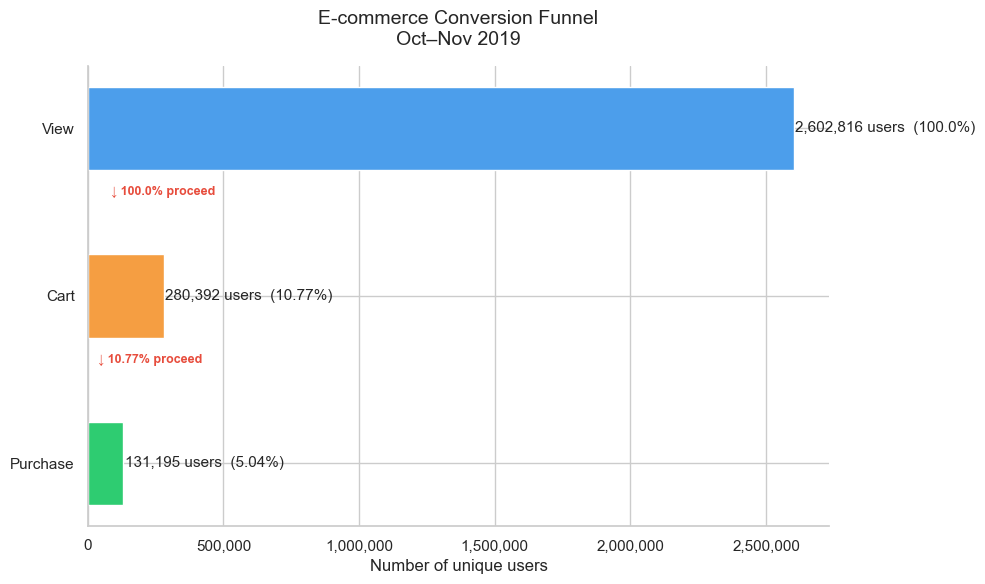


=== KEY INSIGHT ===
Only 5.04% of viewers end up purchasing.
Cart abandonment rate: 53.21%


In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#4C9EEB', '#F59E42', '#2ECC71']
bars = ax.barh(funnel_df['stage'][::-1], 
               funnel_df['users'][::-1], 
               color=colors[::-1], height=0.5)

# Add labels on bars
for bar, row in zip(bars, funnel_df[::-1].itertuples()):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'{row.users:,} users  ({row.conv_from_view}%)',
            va='center', fontsize=11)

# Add step conversion arrows between bars
for i in range(len(funnel_df) - 1):
    stage     = funnel_df.iloc[::-1].iloc[i]
    next_stage = funnel_df.iloc[::-1].iloc[i+1]
    ax.annotate(f'↓ {next_stage.step_conv}% proceed',
                xy=(stage.users * 0.3, i + 0.6),
                fontsize=9, color='#E74C3C', fontweight='bold')

ax.set_title('E-commerce Conversion Funnel\nOct–Nov 2019', fontsize=14, pad=15)
ax.set_xlabel('Number of unique users')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('processed/02_funnel_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== KEY INSIGHT ===")
print(f"Only {funnel_df.iloc[2]['conv_from_view']}% of viewers end up purchasing.")
print(f"Cart abandonment rate: {100 - funnel_df.iloc[2]['step_conv']}%")

In [4]:
monthly_funnel = []

for month in df['month_name'].unique():
    mdf = df[df['month_name'] == month]
    monthly_funnel.append({
        'month'   : month,
        'viewers' : mdf[mdf['event_type'] == 'view']['user_id'].nunique(),
        'carters' : mdf[mdf['event_type'] == 'cart']['user_id'].nunique(),
        'buyers'  : mdf[mdf['event_type'] == 'purchase']['user_id'].nunique()
    })

mf = pd.DataFrame(monthly_funnel)
mf['view_to_cart']     = (mf['carters'] / mf['viewers'] * 100).round(2)
mf['cart_to_purchase'] = (mf['buyers']  / mf['carters'] * 100).round(2)
mf['view_to_purchase'] = (mf['buyers']  / mf['viewers'] * 100).round(2)

print(mf.to_string(index=False))

   month  viewers  carters  buyers  view_to_cart  cart_to_purchase  view_to_purchase
Oct 2019  1365004    72626   60458          5.32             83.25              4.43
Nov 2019  1784605   218034   76691         12.22             35.17              4.30


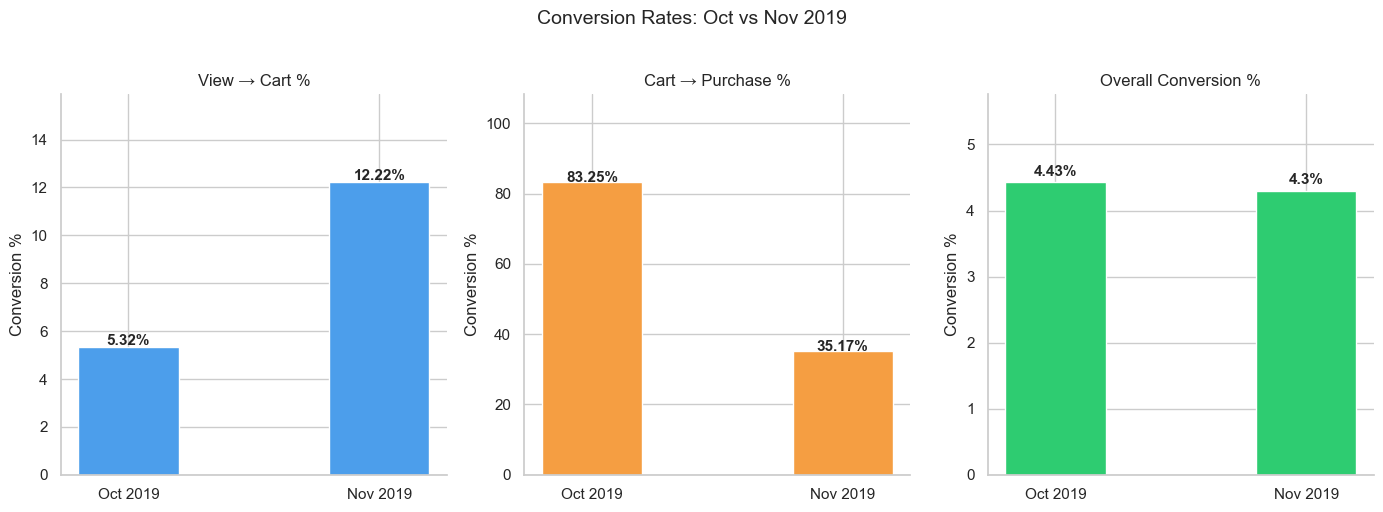

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['view_to_cart', 'cart_to_purchase', 'view_to_purchase']
titles  = ['View → Cart %', 'Cart → Purchase %', 'Overall Conversion %']
colors  = ['#4C9EEB', '#F59E42', '#2ECC71']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    bars = ax.bar(mf['month'], mf[metric], color=color, width=0.4)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Conversion %')
    ax.set_ylim(0, mf[metric].max() * 1.3)
    for bar, val in zip(bars, mf[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f'{val}%', ha='center', fontsize=11, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Conversion Rates: Oct vs Nov 2019', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('processed/03_monthly_conversion.png', dpi=150, bbox_inches='tight')
plt.show()